# E-commerce Lifecycle Analytics  
## Notebook 3: Retention & Engagement Analysis

This notebook focuses on **user retention and engagement behaviour**.

Since the dataset contains activity from **a single month**, traditional multi-month cohort analysis cannot be performed. Instead, we analyze **short-term retention and repeat engagement within the month**.

### Objectives

- Measure **same-day repeat activity**
- Identify **users returning within 7 days**
- Analyze **repeat sessions per user**
- Understand **how frequently users engage with the platform**

### Why this matters

Retention metrics help evaluate whether users return after their first interaction.  
Strong retention usually signals:

- good user experience
- strong product interest
- higher long-term value.

Even in single-month datasets, short-term retention metrics provide valuable lifecycle insights.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [14]:
# Load cleaned dataset from previous notebook

df = pd.read_csv("Data /ecommerce_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1999840, 21)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_day,event_month,event_year,event_hour,day_of_week,year_month,year_week,is_weekend,price_band,main_category,sub_category
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown_category,peda,"1,647.40",532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2019-10-09,9,10,2019,2,Wednesday,2019-10,2019-40,0,1000+,unknown_category,unknown
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,2019-10-21,21,10,2019,16,Monday,2019-10,2019-42,0,100-250,electronics,video
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,2019-10-21,21,10,2019,14,Monday,2019-10,2019-42,0,250-500,electronics,smartphone
3,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,2019-10-03,3,10,2019,18,Thursday,2019-10,2019-39,0,50-100,auto,accessories
4,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown_category,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,2019-10-19,19,10,2019,8,Saturday,2019-10,2019-41,1,0-50,unknown_category,unknown


## 1. Dataset Overview

Before performing retention analysis, we verify the time coverage of the dataset.

Retention analysis typically requires multiple months of activity data.  
If the dataset spans only one month, we instead analyze **within-month retention behaviour**.

In [16]:
# Convert event_time to datetime format

df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

# Check date range of the dataset

print("First Event:", df["event_time"].min())
print("Last Event:", df["event_time"].max())

First Event: 2019-10-01 00:00:24+00:00
Last Event: 2019-10-31 23:59:58+00:00


## 2. Preparing Time Variables

To analyze repeat activity within the month, we extract the **event date** from the timestamp.

This allows us to measure:

- daily activity
- repeat visits
- time between user interactions

In [18]:
# Extract date from event timestamp

df["event_date"] = df["event_time"].dt.date

df[["event_time", "event_date"]].head()

,event_time,event_date
0,2019-10-09 02:46:19+00:00,2019-10-09
1,2019-10-21 16:17:11+00:00,2019-10-21
2,2019-10-21 14:42:20+00:00,2019-10-21
3,2019-10-03 18:40:22+00:00,2019-10-03
4,2019-10-19 08:58:51+00:00,2019-10-19


## 3. Same-Day Repeat Activity

Same-day retention measures how many users perform **multiple interactions on the same day**.

This helps identify users who immediately re-engage with the platform after their first event.

In [20]:
# Count number of events per user per day

user_daily_activity = (
    df.groupby(["user_id", "event_date"])
      .size()
      .reset_index(name="daily_events")
)

user_daily_activity.head()

,user_id,event_date,daily_events
0,195082191,2019-10-10,1
1,219406386,2019-10-16,1
2,228761834,2019-10-13,1
3,239475080,2019-10-25,1
4,239876607,2019-10-09,1


In [21]:
# Users with more than one event in the same day

same_day_repeat_users = user_daily_activity[
    user_daily_activity["daily_events"] > 1
]

same_day_repeat_users.head()

,user_id,event_date,daily_events
12,260013793,2019-10-18,2
13,260013793,2019-10-25,2
17,278043824,2019-10-07,2
26,293335683,2019-10-07,2
31,296894080,2019-10-24,2


In [22]:
# Calculate same-day repeat rate

total_users = df["user_id"].nunique()

repeat_users = same_day_repeat_users["user_id"].nunique()

same_day_retention_rate = repeat_users / total_users

print("Total Users:", total_users)
print("Same-Day Repeat Users:", repeat_users)
print("Same-Day Retention Rate:", round(same_day_retention_rate * 100, 2), "%")

Total Users: 935717
Same-Day Repeat Users: 280390
Same-Day Retention Rate: 29.97 %


## 4. 7-Day Return Behaviour

Early return behaviour is a strong indicator of user engagement.

Here we measure how many users return **within 7 days after their first interaction**.

In [24]:
# Identify the first activity timestamp for each user

first_activity = (
    df.groupby("user_id")["event_time"]
      .min()
      .reset_index()
)

first_activity.columns = ["user_id", "first_event_time"]

first_activity.head()

,user_id,first_event_time
0,195082191,2019-10-10 03:35:36+00:00
1,219406386,2019-10-16 02:55:42+00:00
2,228761834,2019-10-13 08:19:43+00:00
3,239475080,2019-10-25 15:48:17+00:00
4,239876607,2019-10-09 06:57:57+00:00


In [25]:
# Merge first activity back into main dataset

df = df.merge(first_activity, on="user_id", how="left")

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_day,event_month,event_year,event_hour,day_of_week,year_month,year_week,is_weekend,price_band,main_category,sub_category,first_event_time
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown_category,peda,"1,647.40",532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2019-10-09,9,10,2019,2,Wednesday,2019-10,2019-40,0,1000+,unknown_category,unknown,2019-10-09 02:45:26+00:00
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,2019-10-21,21,10,2019,16,Monday,2019-10,2019-42,0,100-250,electronics,video,2019-10-21 16:12:24+00:00
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,2019-10-21,21,10,2019,14,Monday,2019-10,2019-42,0,250-500,electronics,smartphone,2019-10-21 14:42:20+00:00
3,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,2019-10-03,3,10,2019,18,Thursday,2019-10,2019-39,0,50-100,auto,accessories,2019-10-03 18:40:01+00:00
4,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown_category,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,2019-10-19,19,10,2019,8,Saturday,2019-10,2019-41,1,0-50,unknown_category,unknown,2019-10-19 08:58:51+00:00


In [26]:
# Calculate days since first interaction

df["days_since_first_event"] = (
    df["event_time"] - df["first_event_time"]
).dt.days

df[["user_id", "event_time", "days_since_first_event"]].head()

,user_id,event_time,days_since_first_event
0,532353313,2019-10-09 02:46:19+00:00,0
1,536042235,2019-10-21 16:17:11+00:00,0
2,517143806,2019-10-21 14:42:20+00:00,0
3,556492770,2019-10-03 18:40:22+00:00,0
4,561838859,2019-10-19 08:58:51+00:00,0


In [27]:
# Identify users who returned within 7 days

seven_day_return_users = df[
    (df["days_since_first_event"] > 0) &
    (df["days_since_first_event"] <= 7)
]["user_id"].nunique()

seven_day_retention_rate = seven_day_return_users / total_users

print("7-Day Returning Users:", seven_day_return_users)
print("7-Day Retention Rate:", round(seven_day_retention_rate * 100, 2), "%")

7-Day Returning Users: 152299
7-Day Retention Rate: 16.28 %


## 5. Repeat Sessions per User

Another way to measure engagement is by analyzing how many sessions each user generates.

Higher session frequency often indicates stronger platform engagement.

In [29]:
# Count number of sessions per user

user_sessions = (
    df.groupby("user_id")["user_session"]
      .nunique()
      .reset_index()
)

user_sessions.columns = ["user_id", "session_count"]

user_sessions.head()

,user_id,session_count
0,195082191,1
1,219406386,1
2,228761834,1
3,239475080,1
4,239876607,1


In [30]:
# Analyze distribution of session counts

session_distribution = (
    user_sessions["session_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

session_distribution.columns = ["session_count", "user_count"]

session_distribution.head(10)

,session_count,user_count
0,1,637961
1,2,162733
2,3,63267
3,4,29990
4,5,15673
5,6,8830
6,7,5436
7,8,3456
8,9,2235
9,10,1540


In [35]:
# ---------------------------------------------
# Engagement summary metrics
# ---------------------------------------------

# Average sessions per user
avg_sessions_per_user = user_sessions["session_count"].mean()

# Create summary table
engagement_summary = pd.DataFrame({
    "metric": [
        "Same-Day Retention",
        "7-Day Retention",
        "Average Sessions per User"
    ],
    "value": [
        same_day_retention_rate * 100,
        seven_day_retention_rate * 100,
        avg_sessions_per_user
    ]
})

engagement_summary

,metric,value
0,Same-Day Retention,29.97
1,7-Day Retention,16.28
2,Average Sessions per User,1.68


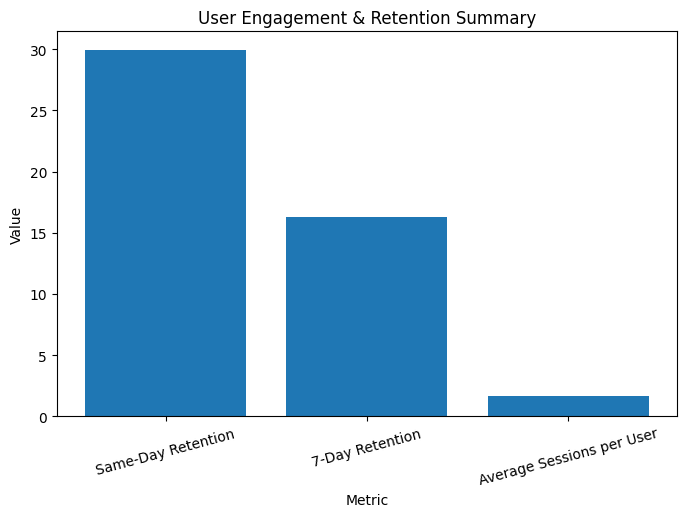

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    engagement_summary["metric"],
    engagement_summary["value"]
)

plt.title("User Engagement & Retention Summary")
plt.ylabel("Value")
plt.xlabel("Metric")

plt.xticks(rotation=15)

plt.show()

## 6. Engagement Summary

This analysis evaluates short-term engagement behaviour within the dataset by examining how frequently users return and interact with the platform.

### Same-Day Engagement

Approximately **29.97% of users performed multiple actions on the same day** as their first interaction.  
This suggests that nearly one-third of users explore multiple products or pages during their initial visit, indicating moderate immediate engagement with the platform.

### Early Return Behaviour

Around **16.28% of users returned within 7 days of their first interaction**.  
While this shows that a portion of users revisit the platform shortly after their first visit, the majority of users do not return within the first week. This indicates that early user retention may be an area where engagement strategies could be strengthened.

### Session Frequency

Users generate an average of **1.68 sessions per user** during the month.  
The session distribution shows that most users interact with the platform only once, while a smaller group of users returns multiple times. This pattern is typical for many e-commerce platforms, where a large share of traffic consists of casual visitors.

### Engagement Interpretation

Overall, the engagement metrics suggest that:

- many users explore the platform briefly
- a smaller portion returns within the first week
- repeat interaction is concentrated among a smaller subset of users

Improving early engagement and encouraging repeat visits could help strengthen user retention and increase the likelihood of users progressing further in the purchase journey.